In [1]:
using DifferentialEquations
using ReactionMechanismSimulator
using PyPlot

In [2]:
outdict1 = readinput("Cu_012925.rms")

[21:03:36] WARNING: not removing hydrogen atom without neighbors
[21:03:36] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.j

Dict{Any, Any} with 4 entries:
  "Solvents"              => Solvent[Solvent("water", RiedelViscosity{Float64}(…
  Set(["surface", "gas"]) => Dict{Any, Any}("Reactions"=>ElementaryReaction[vac…
  "gas"                   => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…
  "surface"               => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…

In [3]:
liqspcs1 = outdict1["gas"]["Species"];
liqrxns1 = outdict1["gas"]["Reactions"];
surfspcs1 = outdict1["surface"]["Species"];
surfrxns1 = outdict1["surface"]["Reactions"];
interfacerxns1 = outdict1[Set(["surface", "gas"])]["Reactions"];
solv1 = outdict1["Solvents"][1];

In [4]:
sitedensity1 = 2.943e-5; # Cu111
sitedensity2 = 2.292e-5; # Ag111
AVratio = 36;
Phi1 = -1.914;
Phi2 = -1.414;
Phi3 = -0.914;

In [5]:
initialcondsliq = Dict(["proton"=>10.0^-4,"CO2"=>10.0^-3*10^3,
        "V"=>1.0,"T"=>298.15,"Phi"=>0.0,"d"=>0.0]);
initialcondssurf1 = Dict(["CO2X"=>0.4*sitedensity1*AVratio,
        "CHO2X"=>0.1*sitedensity1*AVratio,
        "CO2HX"=>0.1*sitedensity1*AVratio,
        "OX"=>0.1*sitedensity1*AVratio,
        "OCX"=>0.1*sitedensity1*AVratio,
        "vacantX"=>0.1*sitedensity1*AVratio,
        "CH2O2X"=>0.05*sitedensity1*AVratio,
        "CHOX"=>0.04*sitedensity1*AVratio,
        "CH2OX"=>0.01*sitedensity1*AVratio,
        "A"=>1.0*AVratio,"T"=>298.15,"Phi"=>Phi1]);

In [6]:
initialcondssurf2 = Dict(["CO2X"=>0.4*sitedensity1*AVratio,
        "CHO2X"=>0.1*sitedensity1*AVratio,
        "CO2HX"=>0.1*sitedensity1*AVratio,
        "OX"=>0.1*sitedensity1*AVratio,
        "OCX"=>0.1*sitedensity1*AVratio,
        "vacantX"=>0.1*sitedensity1*AVratio,
        "CH2O2X"=>0.05*sitedensity1*AVratio,
        "CHOX"=>0.04*sitedensity1*AVratio,
        "CH2OX"=>0.01*sitedensity1*AVratio,
        "A"=>1.0*AVratio,"T"=>298.15,"Phi"=>Phi2]);

In [7]:
initialcondssurf3 = Dict(["CO2X"=>0.4*sitedensity1*AVratio,
        "CHO2X"=>0.1*sitedensity1*AVratio,
        "CO2HX"=>0.1*sitedensity1*AVratio,
        "OX"=>0.1*sitedensity1*AVratio,
        "OCX"=>0.1*sitedensity1*AVratio,
        "vacantX"=>0.1*sitedensity1*AVratio,
        "CH2O2X"=>0.05*sitedensity1*AVratio,
        "CHOX"=>0.04*sitedensity1*AVratio,
        "CH2OX"=>0.01*sitedensity1*AVratio,
        "A"=>1.0*AVratio,"T"=>298.15,"Phi"=>Phi3]);

In [8]:
liq1 = IdealDiluteSolution(liqspcs1,liqrxns1,solv1,name="liquid",diffusionlimited=true);

surf1 = IdealSurface(surfspcs1,surfrxns1,sitedensity1,name="surface");


In [9]:
domainliq1,y0liq1,pliq1 = ConstantTVDomain(phase=liq1,
    initialconds=initialcondsliq,constantspecies=["proton","CO2"]);

In [10]:
domaincat1,y0cat1,pcat1 = ConstantTAPhiDomain(phase=surf1,
    initialconds=initialcondssurf1);

inter1,pinter1 = ReactiveInternalInterfaceConstantTPhi(domainliq1,
  domaincat1,interfacerxns1,298.15,AVratio*1.0);

In [11]:
domaincat2,y0cat2,pcat2 = ConstantTAPhiDomain(phase=surf1,
    initialconds=initialcondssurf2);

inter2,pinter2 = ReactiveInternalInterfaceConstantTPhi(domainliq1,
    domaincat2,interfacerxns1,298.15,AVratio*1.0);

In [12]:
domaincat3,y0cat3,pcat3 = ConstantTAPhiDomain(phase=surf1,
    initialconds=initialcondssurf3);

inter3,pinter3 = ReactiveInternalInterfaceConstantTPhi(domainliq1,
    domaincat3,interfacerxns1,298.15,AVratio*1.0);

In [13]:
@time react1,y01,p1 = Reactor((domainliq1,domaincat1), (y0liq1,y0cat1), (0.0, 1.0e3), [inter1], (pliq1,pcat1,pinter1));

@time sol1 = solve(react1.ode,DifferentialEquations.CVODE_BDF(),abstol=1e-16,reltol=1e-8);

ssys1 = SystemSimulation(sol1,(domainliq1,domaincat1,),(inter1,),p1);

 11.263037 seconds (50.51 M allocations: 3.023 GiB, 10.83% gc time, 99.93% compilation time: <1% of which was recompilation)
  4.120459 seconds (19.06 M allocations: 1.224 GiB, 8.81% gc time, 96.98% compilation time)


In [14]:
@time react2,y02,p2 = Reactor((domainliq1,domaincat2), (y0liq1,y0cat2), (0.0, 1.0e3), [inter2], (pliq1,pcat2,pinter2));

@time sol2 = solve(react2.ode,DifferentialEquations.CVODE_BDF(),abstol=1e-16,reltol=1e-8);

ssys2 = SystemSimulation(sol2,(domainliq1,domaincat2,),(inter2,),p2);

  0.001494 seconds (6.54 k allocations: 3.020 MiB)
  0.083375 seconds (351.54 k allocations: 101.750 MiB, 31.75% gc time)


In [15]:
@time react3,y02,p3 = Reactor((domainliq1,domaincat3), (y0liq1,y0cat3), (0.0, 1.0e3), [inter3], (pliq1,pcat3,pinter3));

@time sol3 = solve(react3.ode,DifferentialEquations.CVODE_BDF(),abstol=1e-16,reltol=1e-8);

ssys3 = SystemSimulation(sol3,(domainliq1,domaincat3,),(inter3,),p3);

  0.001466 seconds (6.54 k allocations: 3.020 MiB)
  0.111071 seconds (553.96 k allocations: 145.146 MiB, 19.69% gc time)


In [ ]:
# Plot liquid phase mole fractions
function plotXL(bsol, tol, t_end, exclude)
    # Species order and corresponding colors for the main species
    species_order = ["CO2", "proton", "H2", "CH4", "O=CO", "C=O", "CO-2", "OCCO"]
    color_map = Dict("CO2" => "magenta", "proton" => "black", "H2" => "blue",
                     "CH4" => "red", "O=CO" => "green", "C=O" => "purple",
                     "CO-2" => "brown", "OCCO" => "grey")
    # Replacement map for species labels
    replacement_map = Dict("O=CO" => "HCOOH", "C=O" => "HCHO", "CO-2" => "CH3OH",
                           "OCCO" => "HOCH2CH2OH")

    clf()
    xs = molefractions(bsol)
    maxes = maximum(xs, dims=2)
    spnames = []
    plotted_species = Set{String}()

    # Filter data to the specified time range
    if t_end !== nothing
        t_mask = bsol.sol.t .<= t_end
        ts = bsol.sol.t[t_mask]
        xs = xs[:, t_mask]
    else
        ts = bsol.sol.t
    end

    # Plot species in the specified order with custom colors and labels
    for sp in species_order
        # Find the species index in the phase
        species_index = findfirst(x -> x.name == sp, bsol.domain.phase.species)
        if species_index === nothing || maxes[species_index] <= tol || sp in exclude
            continue
        end

        # Apply replacement for display name if available
        display_name = get(replacement_map, sp, sp)

        # Plot the species with the specified color
        plot(ts, xs[species_index, :], label=display_name, color=color_map[sp])
        push!(spnames, display_name)
        push!(plotted_species, sp)
    end

    # Plot any remaining species that are above the tolerance and not already plotted
    for i = 1:length(bsol.domain.phase.species)
        sp = bsol.domain.phase.species[i].name
        if maxes[i] > tol && !(sp in exclude) && !(sp in plotted_species)
            plot(ts, xs[i, :], label=sp)
            push!(spnames, sp)
        end
    end

    # Configure the legend and labels
    xlabel("Time (s)", fontsize=16)
    ylabel("Mole Fraction", fontsize=16)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(spnames, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12, ncol=1)
end

plotXL (generic function with 1 method)

In [ ]:
# Plot surface coverages
function plotXS(bsol, tol, t_end, exclude)
    # Species order and corresponding colors for the main species
    species_order = ["vacantX", "CO2X", "[H][H].[Pt]", "CH2O2X", "OCX", "CHOX", "OC[Pt]", "CO.[Pt]", "OCO[Pt]"]
    color_map = Dict("vacantX" => "magenta", "CO2X" => "black", "[H][H].[Pt]" => "blue",
                     "CH2O2X" => "red", "OCX" => "green", "CHOX" => "purple",
                     "OC[Pt]" => "brown", "CO.[Pt]" => "grey", "OCO[Pt]" => "cyan")
    # Replacement map for species labels
    replacement_map = Dict("vacantX" => "vacancies", "[H][H].[Pt]" => "H2X",
                           "OCX" => "COX", "CH2O2X" => "HCOOHX", "CO.[Pt]" => "CH3OHX",
                           "OC[Pt]" => "CH2OHX", "OCO[Pt]" => "OCH2OHX")

    clf()
    xs = molefractions(bsol)
    maxes = maximum(xs, dims=2)
    spnames = []
    plotted_species = Set{String}()

    # Filter data to the specified time range
    if t_end !== nothing
        t_mask = bsol.sol.t .<= t_end
        ts = bsol.sol.t[t_mask]
        xs = xs[:, t_mask]
    else
        ts = bsol.sol.t
    end

    # Plot species in the specified order with custom colors and labels
    for sp in species_order
        # Find the species index in the phase
        species_index = findfirst(x -> x.name == sp, bsol.domain.phase.species)
        if species_index === nothing || maxes[species_index] <= tol || sp in exclude
            continue
        end

        # Apply replacement for display name if available
        display_name = get(replacement_map, sp, sp)

        # Plot the species with the specified color
        plot(ts, xs[species_index, :], label=display_name, color=color_map[sp])
        push!(spnames, display_name)
        push!(plotted_species, sp)
    end

    # Plot any remaining species that are above the tolerance and not already plotted
    for i = 1:length(bsol.domain.phase.species)
        sp = bsol.domain.phase.species[i].name
        if maxes[i] > tol && !(sp in exclude) && !(sp in plotted_species)
            plot(ts, xs[i, :], label=sp)
            push!(spnames, sp)
        end
    end

    # Configure the legend and labels
    xlabel("Time (s)", fontsize=16)
    ylabel("Surface Coverage", fontsize=16)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(spnames, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12, ncol=1)
end

plotXS (generic function with 1 method)

In [ ]:
# Plot liquid-phase concentrations
function plotCL(bsol, tol, t_end, exclude)
    # Species order and corresponding colors for the main species
    species_order = ["CO2", "proton", "H2", "CH4", "O=CO", "C=O", "CO-2", "OCCO"]
    color_map = Dict("CO2" => "magenta", "proton" => "black", "H2" => "blue",
                        "CH4" => "red", "O=CO" => "green", "C=O" => "purple",
                        "CO-2" => "brown", "OCCO" => "grey")
    # Replacement map for species labels
    replacement_map = Dict("O=CO" => "HCOOH", "C=O" => "HCHO", "CO-2" => "CH3OH",
                            "OCCO" => "HOCH2CH2OH")

    clf()
    xs = concentrations(bsol)
    maxes = maximum(xs, dims=2)
    spnames = []
    plotted_species = Set{String}()

    # Filter data to the specified time range
    if t_end !== nothing
        t_mask = bsol.sol.t .<= t_end
        ts = bsol.sol.t[t_mask]
        xs = xs[:, t_mask]
    else
        ts = bsol.sol.t
    end

    # Plot species in the specified order with custom colors and labels
    for sp in species_order
        # Find the species index in the phase
        species_index = findfirst(x -> x.name == sp, bsol.domain.phase.species)
        if species_index === nothing || maxes[species_index] <= tol || sp in exclude
            continue
        end

        # Apply replacement for display name if available
        display_name = get(replacement_map, sp, sp)

        # Plot the species with the specified color
        plot(ts, xs[species_index, :], label=display_name, color=color_map[sp])
        push!(spnames, display_name)
        push!(plotted_species, sp)
    end

    # Plot any remaining species that are above the tolerance and not already plotted
    for i = 1:length(bsol.domain.phase.species)
        sp = bsol.domain.phase.species[i].name
        if maxes[i] > tol && !(sp in exclude) && !(sp in plotted_species)
            plot(ts, xs[i, :], label=sp)
            push!(spnames, sp)
        end
    end

    # Configure the legend and labels
    xlabel("Time (s)", fontsize=16)
    ylabel("Concentration (mol/m^3)", fontsize=16)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(spnames, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12, ncol=1)
end

plotCL (generic function with 1 method)

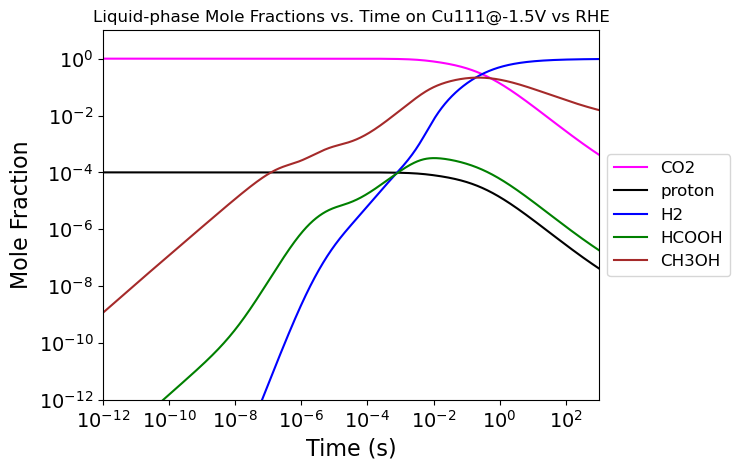

In [19]:
exclude_species = ["H2O"]
plotXL(ssys1.sims[1], 1e-8, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 1e1)
title("Liquid-phase Mole Fractions vs. Time on Cu111@-1.5V vs RHE")
gcf()

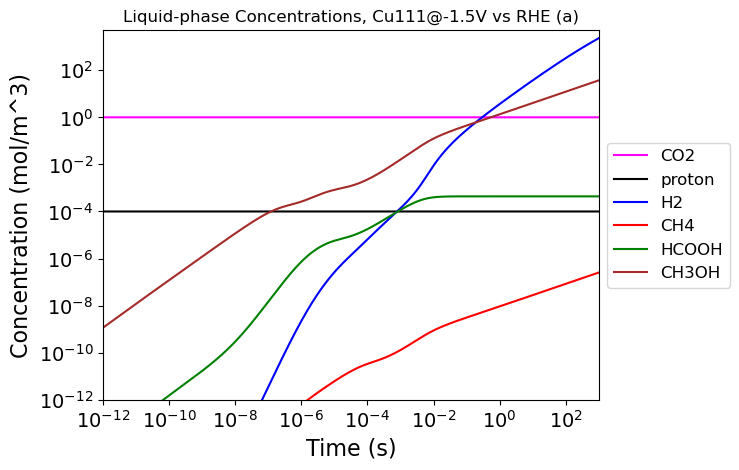

In [34]:
exclude_species = ["H2O"]
plotCL(ssys1.sims[1], 1e-8, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 5e3)
title("Liquid-phase Concentrations, Cu111@-1.5V vs RHE (a)")
gcf()

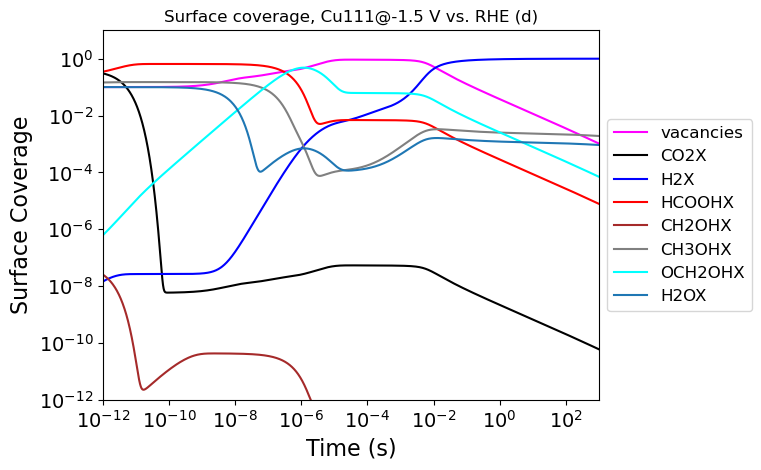

In [35]:
exclude_species = ["H2O"]
plotXS(ssys1.sims[2], 0.1, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 1e1)
title("Surface coverage, Cu111@-1.5 V vs. RHE (d)")
gcf()

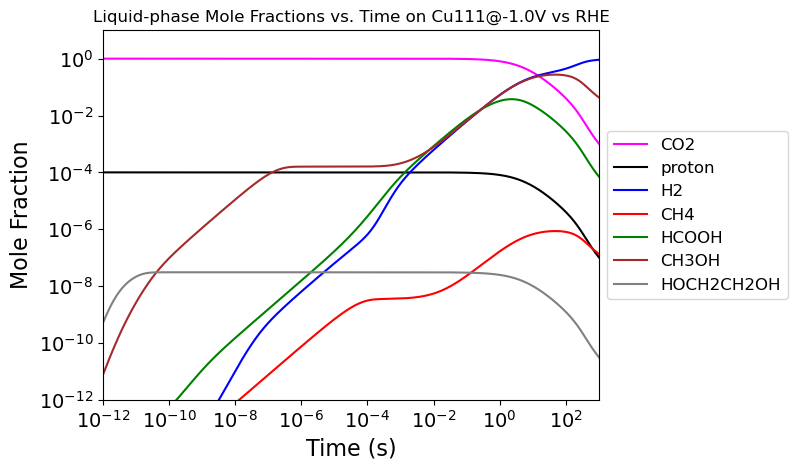

In [22]:
exclude_species = ["H2O"]
plotXL(ssys2.sims[1], 1e-8, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 1e1)
title("Liquid-phase Mole Fractions vs. Time on Cu111@-1.0V vs RHE")
gcf()

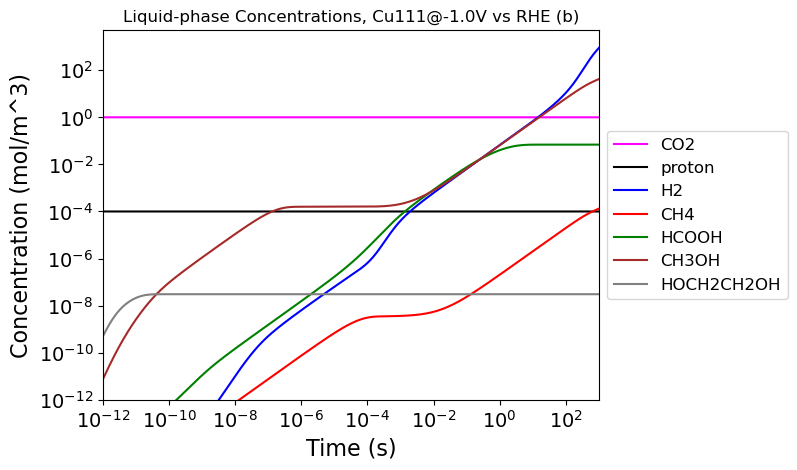

In [36]:
exclude_species = ["H2O"]
plotCL(ssys2.sims[1], 1e-8, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 5e3)
title("Liquid-phase Concentrations, Cu111@-1.0V vs RHE (b)")
gcf()

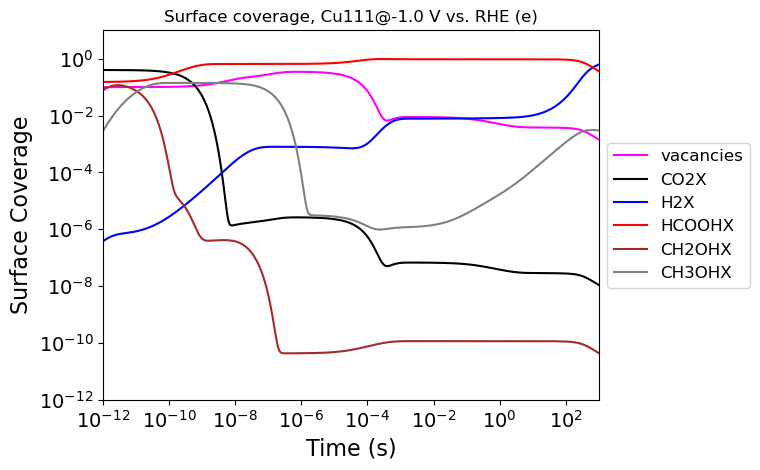

In [37]:
exclude_species = ["H2O"]
plotXS(ssys2.sims[2], 0.1, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 1e1)
title("Surface coverage, Cu111@-1.0 V vs. RHE (e)")
gcf()

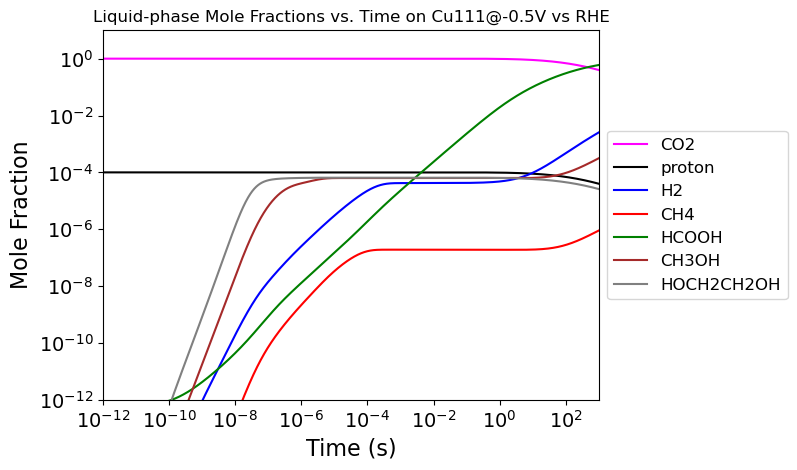

In [25]:
exclude_species = ["H2O"]
plotXL(ssys3.sims[1], 1e-8, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 1e1)
title("Liquid-phase Mole Fractions vs. Time on Cu111@-0.5V vs RHE")
gcf()

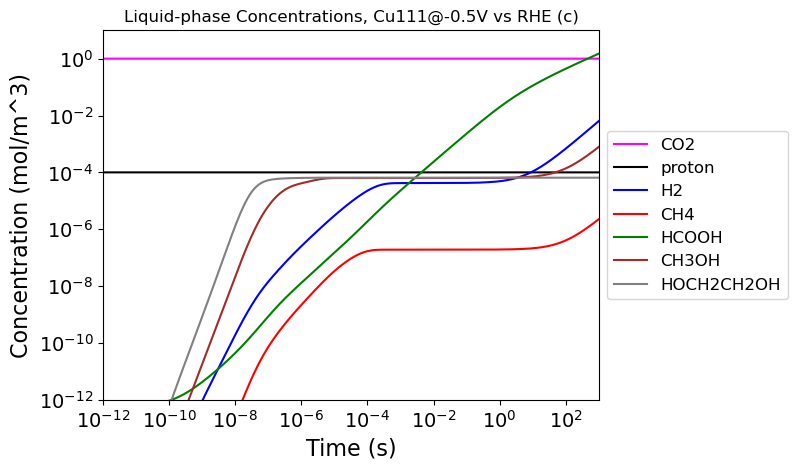

In [38]:
exclude_species = ["H2O"]
plotCL(ssys3.sims[1], 1e-8, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 1e1)
title("Liquid-phase Concentrations, Cu111@-0.5V vs RHE (c)")
gcf()

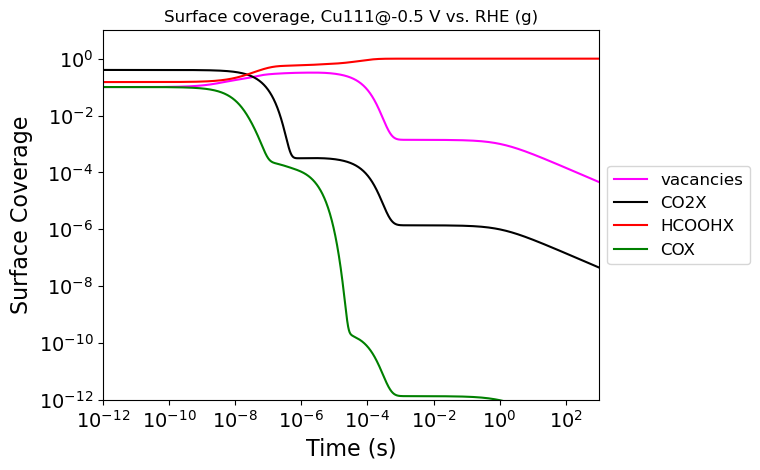

In [39]:
exclude_species = ["H2O"]
plotXS(ssys3.sims[2], 0.1, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 1e1)
title("Surface coverage, Cu111@-0.5 V vs. RHE (g)")
gcf()

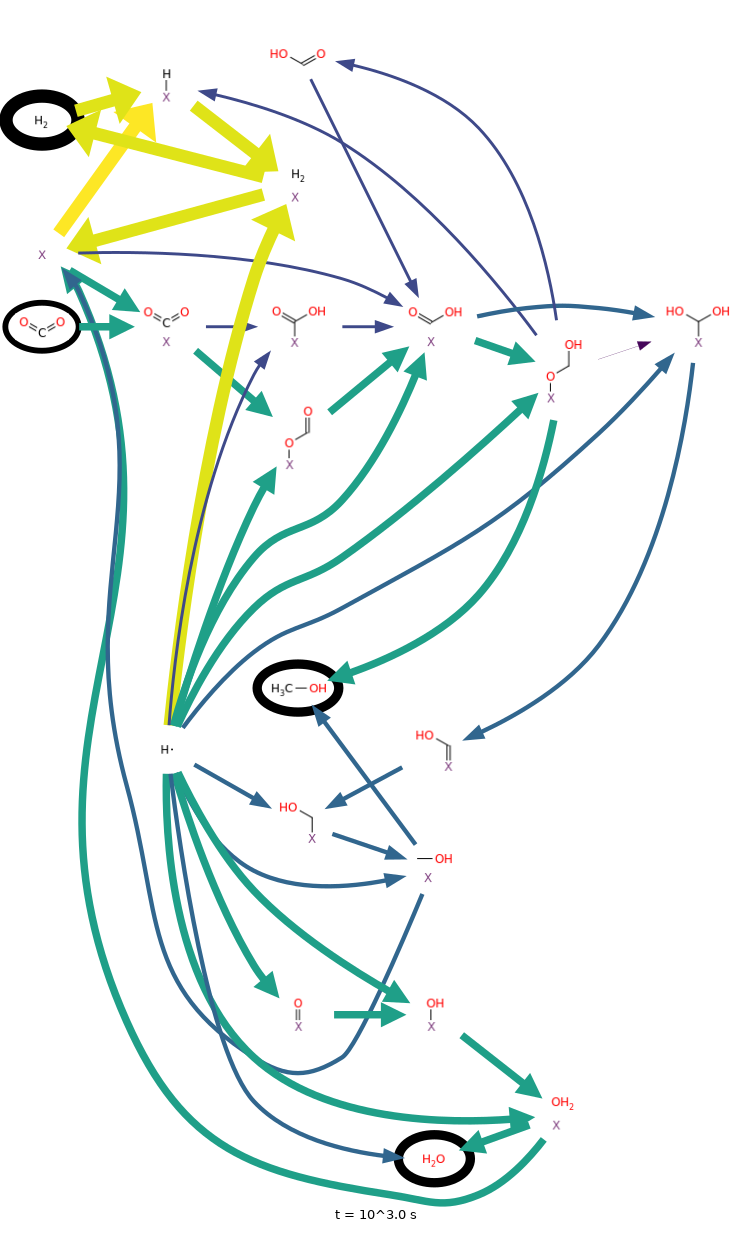

In [41]:
fd1 = getfluxdiagram(ssys1,1e3;speciesratetolerance=1e-6)